## Neural Network Classification 
- Eg: classifying mail spam or not (1 or 0)

### 1. Importing Data and Visualizing

In [1]:
# # creating datasets from sklearn.dataset 
# import sklearn 

# # make_circles dataset
# from sklearn.datasets import make_circles

# # number of samples 
# n_samples = 1000

# # Features and Labels 
# X, y = make_circles(n_samples, 
#                     noise=0.3, 
#                     random_state=42)

In [2]:
from sklearn.datasets import make_circles


# Make 1000 samples 
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [3]:
# Length and shape of X and y 
print(f"Length of X : {len(X)} and Length of y: {len(y)}\n")
print(f"Shape of X : {(X.shape)} and Shape of y: {(y.shape)}\n")

Length of X : 1000 and Length of y: 1000

Shape of X : (1000, 2) and Shape of y: (1000,)



In [4]:
# print some few features and labels 
print(f" X : {(X[:5])}\ny: {(y[:5])}\n")

 X : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
y: [1 1 1 1 0]



In [5]:
# Convert data into DataFrame using pandas 
import pandas as pd 

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y
                        })
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


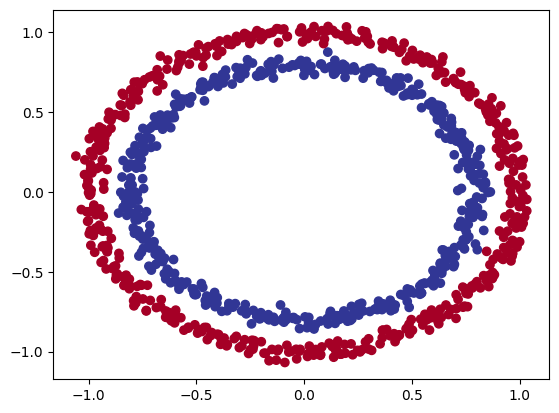

In [6]:
# visualize data 
import matplotlib.pyplot as plt 

plt.scatter(x=X[:, 0], y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu)

In [7]:
# converting numpy type into tensor 
print(f"Before converting into tensor, X and y type : {type(X), type(y)}")

Before converting into tensor, X and y type : (<class 'numpy.ndarray'>, <class 'numpy.ndarray'>)


In [8]:
import torch 
X.dtype

dtype('float64')

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [10]:
print(f"After converting into tensor, X and y type : {type(X), type(y)}")

After converting into tensor, X and y type : (<class 'torch.Tensor'>, <class 'torch.Tensor'>)


In [11]:
# lets print some of them 
print(f"X :{X[:5]}\ny: {y[:5]}")

X :tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])
y: tensor([1., 1., 1., 1., 0.])


In [12]:
X.shape , y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [13]:
# splitting data into training and testing sets 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)


In [14]:
# shape and size 
print(f"Shape of X_train: {X_train.shape} and len: {len(X_train)}")
print(f"Shape of y_train: {y_train.shape} and len: {len(y_train)}\n")

print(f"Shape of X_test: {X_test.shape} and len: {len(X_test)}")
print(f"Shape of y_test: {y_test.shape} and len: {len(y_test)}")

Shape of X_train: torch.Size([800, 2]) and len: 800
Shape of y_train: torch.Size([800]) and len: 800

Shape of X_test: torch.Size([200, 2]) and len: 200
Shape of y_test: torch.Size([200]) and len: 200


### 2. Building Model 
- 1: Setting up device agnoistic code 
- 2: Construct model (by subclassing nn.Module)
- 3: Define loss function and optimizer 
- 4: Define training and testing loop 


In [15]:
# device agonistic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
import torch 
from torch import nn

In [17]:
# Construct model (by subclassing nn.Module)
class NNClassificationModel0(nn.Module):
    def __init__(self):
        super().__init__()
        # create 2 layer using nn.Linear 
        self.layer_1 = nn.Linear(in_features=2, out_features=8)
        self.layer_2 = nn.Linear(in_features=8, out_features=1)
        
    # forward pass method 
    def forward(self, x):
        return self.layer_2(self.layer_1(x))

# create instance of our model class and send to target device 
model_0 = NNClassificationModel0().to(device)
model_0
    

NNClassificationModel0(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [19]:
# Replicating same code using nn.Sequential 
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=8),
    nn.Linear(in_features=8, out_features=1)
).to(device)

In [20]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.6865, -0.5582],
                      [ 0.6125, -0.5445],
                      [-0.6546, -0.1186],
                      [-0.3906, -0.6610],
                      [ 0.2690,  0.1878],
                      [ 0.0267, -0.0117],
                      [ 0.5685,  0.5239],
                      [-0.0822, -0.3775]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6931,  0.0676, -0.1415,  0.6241, -0.3096,  0.4242, -0.1131, -0.6893],
                     device='cuda:0')),
             ('1.weight',
              tensor([[-0.1688, -0.2265, -0.2936, -0.1784,  0.0136,  0.1439,  0.1272,  0.2456]],
                     device='cuda:0')),
             ('1.bias', tensor([0.1269], device='cuda:0'))])

In [21]:
# Making prediction 
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
    
print(f"Untrained Model Predictions:\n{torch.round(untrained_preds[:10])}")
print(f"Actual Label:\n{y_test[:10]}")


Untrained Model Predictions:
tensor([[0.],
        [0.],
        [-0.],
        [0.],
        [-0.],
        [-0.],
        [0.],
        [-0.],
        [-0.],
        [0.]], device='cuda:0')
Actual Label:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [22]:
# Loss and Optimizer 
loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params= model_0.parameters(), 
                            lr=0.01)

# Accuracy Function 
def accuracy_fn(y_true, y_pred): 
    accuracy = torch.eq(y_true, y_pred).sum().item()
    return (accuracy/len(y_pred)) * 100

In [23]:
# Building Training and Testing Loop 
# torch.cuda.manual_seed(42)
torch.manual_seed(42)

# set number of epochs 
epochs = 500

# put data to target device 
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop 
for epoch in range(epochs):
    # Model Train 
    model_0.train()
    
    # 1. Forward Pass 
    y_logits = model_0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    
    # 2. Calculate the loss 
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
    
    # 3. optimizer zero grad 
    optimizer.zero_grad()
    
    # 4. loss backward (backpropagation)
    train_loss.backward()
    
    # 5. optimizer step (gradient descent)
    optimizer.step()
    
    
    ## Testing/Eval 
    model_0.eval()
    with torch.inference_mode():
        # forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # loss 
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
        
    
    if epoch % 50 == 0:
        print(f"Epoch: {epoch}| Train Accuracy: {train_acc}% | Train Loss: {train_loss} |" + 
              f"Test Accuracy: {test_acc}% | Test Loss; {test_loss}")
        

Epoch: 0| Train Accuracy: 47.125% | Train Loss: 0.7027470469474792 |Test Accuracy: 48.0% | Test Loss; 0.7114327549934387
Epoch: 50| Train Accuracy: 49.0% | Train Loss: 0.6986405849456787 |Test Accuracy: 46.0% | Test Loss; 0.7069310545921326
Epoch: 100| Train Accuracy: 50.0% | Train Loss: 0.6965574622154236 |Test Accuracy: 45.5% | Test Loss; 0.7043781876564026
Epoch: 150| Train Accuracy: 50.24999999999999% | Train Loss: 0.6954426169395447 |Test Accuracy: 46.0% | Test Loss; 0.7027861475944519
Epoch: 200| Train Accuracy: 50.875% | Train Loss: 0.6948027014732361 |Test Accuracy: 45.0% | Test Loss; 0.7016897201538086
Epoch: 250| Train Accuracy: 51.0% | Train Loss: 0.6944035291671753 |Test Accuracy: 46.0% | Test Loss; 0.7008656859397888
Epoch: 300| Train Accuracy: 50.875% | Train Loss: 0.6941324472427368 |Test Accuracy: 46.0% | Test Loss; 0.7002043128013611
Epoch: 350| Train Accuracy: 51.74999999999999% | Train Loss: 0.6939343214035034 |Test Accuracy: 46.5% | Test Loss; 0.6996493339538574
Epo

helper_function.py

"""
A series of helper functions used throughout the course.

If a function gets defined once and could be used over and over, it'll go in here.
"""
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch import nn

import os
import zipfile

from pathlib import Path

import requests

# Walk through an image classification directory and find out how many files (images)
# are in each subdirectory.
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    Args:
    dir_path (str): target directory

    Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})


# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def print_train_time(start, end, device=None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time


# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


# Pred and plot image function from notebook 04
# See creation: https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function
from typing import List
import torchvision


def pred_and_plot_image(
    model: torch.nn.Module,
    image_path: str,
    class_names: List[str] = None,
    transform=None,
    device: torch.device = "cuda" if torch.cuda.is_available() else "cpu",
):
    """Makes a prediction on a target image with a trained model and plots the image.

    Args:
        model (torch.nn.Module): trained PyTorch image classification model.
        image_path (str): filepath to target image.
        class_names (List[str], optional): different class names for target image. Defaults to None.
        transform (_type_, optional): transform of target image. Defaults to None.
        device (torch.device, optional): target device to compute on. Defaults to "cuda" if torch.cuda.is_available() else "cpu".
    
    Returns:
        Matplotlib plot of target image and model prediction as title.

    Example usage:
        pred_and_plot_image(model=model,
                            image="some_image.jpeg",
                            class_names=["class_1", "class_2", "class_3"],
                            transform=torchvision.transforms.ToTensor(),
                            device=device)
    """

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.0

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(
        target_image.squeeze().permute(1, 2, 0)
    )  # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False)

def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

In [24]:
# Visualize 
import requests 
from pathlib import Path 

if Path("helper_function.py").is_file():
    print("Exists")
else: 
    print("Downloading helper_function.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open('helper_function.py', 'wb') as f: 
        f.write(request.content)
    

In [25]:
import os
print(os.getcwd())

/content


In [26]:
from helper_function import plot_predictions, plot_decision_boundary

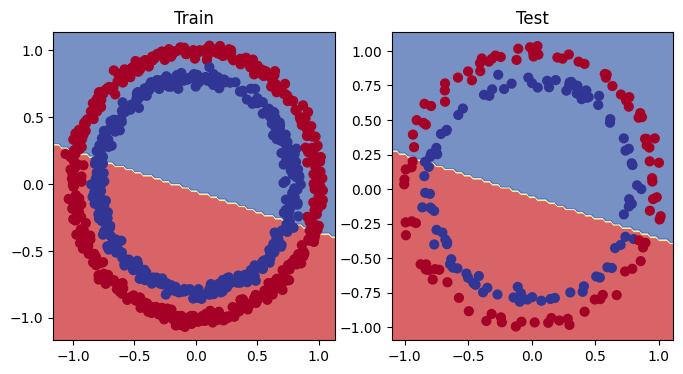

In [27]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train,y_train )

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

### Improving Model 


In [28]:
import torch 
from torch import nn

In [29]:
# Creating child class using nn.Module
class NNClassificationModel1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer_1 = nn.Linear(in_features=2, out_features=32)
        self.layer_2 = nn.Linear(in_features=32, out_features=64)
        self.layer_3 = nn.Linear(in_features=64, out_features=1)
        self.relu = nn.ReLU() # ReLU activation max(0, z)
        
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
# instance of class NNClassificationModel1() and setting to cuda device 
model_1 = NNClassificationModel1().to(device)
model_1

NNClassificationModel1(
  (layer_1): Linear(in_features=2, out_features=32, bias=True)
  (layer_2): Linear(in_features=32, out_features=64, bias=True)
  (layer_3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

In [30]:
# Loss and Optimizer 
loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(params= model_1.parameters(), 
                            lr=0.01)

In [31]:
# training and testing 
torch.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs): 
    model_1.train()
    
    # 1. Forward pass 
    train_logits = model_1(X_train).squeeze()
    train_preds = torch.round(torch.sigmoid(train_logits))
    
    # 2. Loss + Accuracy
    train_loss = loss_fn(train_logits, y_train)
    train_acc = accuracy_fn(y_true=y_train, y_pred=train_preds)
    
    # 3. Zero grad
    optimizer.zero_grad()
    
    # 4. Backprop
    train_loss.backward()
    
    # 5. Optimizer step
    optimizer.step()
    
    
    ## Evaluation
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
        
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | "
              f"Train Acc: {train_acc:.2f}% | Train Loss: {train_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")
      

Epoch: 0 | Train Acc: 50.00% | Train Loss: 0.6933 | Test Acc: 50.00% | Test Loss: 0.6901
Epoch: 10 | Train Acc: 72.88% | Train Loss: 0.6377 | Test Acc: 77.00% | Test Loss: 0.6368
Epoch: 20 | Train Acc: 99.75% | Train Loss: 0.4519 | Test Acc: 98.00% | Test Loss: 0.4470
Epoch: 30 | Train Acc: 99.88% | Train Loss: 0.1757 | Test Acc: 100.00% | Test Loss: 0.1803
Epoch: 40 | Train Acc: 100.00% | Train Loss: 0.0413 | Test Acc: 100.00% | Test Loss: 0.0578
Epoch: 50 | Train Acc: 100.00% | Train Loss: 0.0126 | Test Acc: 100.00% | Test Loss: 0.0249
Epoch: 60 | Train Acc: 100.00% | Train Loss: 0.0061 | Test Acc: 100.00% | Test Loss: 0.0157
Epoch: 70 | Train Acc: 100.00% | Train Loss: 0.0040 | Test Acc: 100.00% | Test Loss: 0.0120
Epoch: 80 | Train Acc: 100.00% | Train Loss: 0.0031 | Test Acc: 100.00% | Test Loss: 0.0097
Epoch: 90 | Train Acc: 100.00% | Train Loss: 0.0025 | Test Acc: 100.00% | Test Loss: 0.0086


In [32]:
# EVALUATION 
model_1.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_1(X_test))).squeeze()
    
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

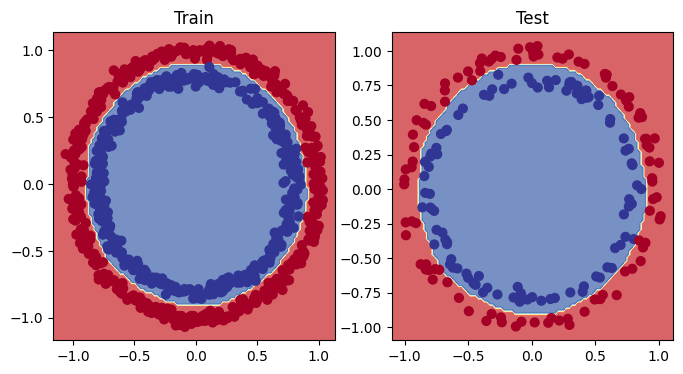

In [33]:
# plot_decision_boundry 
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)


plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## BUILDING MULTI-CLASS CLASSIFICATION MODEL 
which means multiple output. Eg: Prediction whether a number is 0-9, ...

### 1. Importing Dataset and Visualizing 

In [ ]:
# importing necessary libraries
import torch 
from torch import nn 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

In [38]:
# TOY DATASET
# initialiing hyperparameteres 
INPUT_FEATURES = 2
OUTPUT_FEATURES = 5
HIDDEN_UNITS = 16
RANDOM_STATE = 42

# create multi class dataset
X_blob , y_blob = make_blobs(  n_samples= 2000, 
                             n_features= INPUT_FEATURES, 
                             centers= OUTPUT_FEATURES, 
                             cluster_std= 1.5, 
                             random_state= RANDOM_STATE)

# turn data into tensors 
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

In [39]:
# split into train and test 
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_STATE)

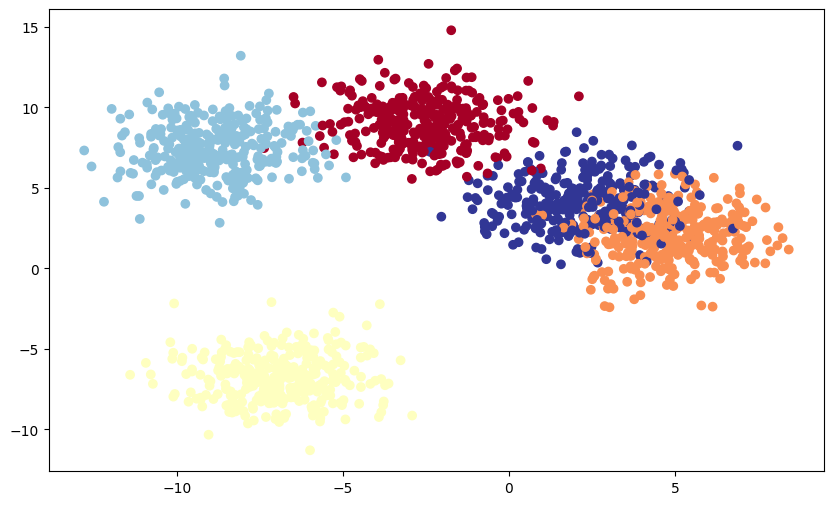

In [44]:
# visualize training data 
plt.figure(figsize=(10,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=plt.cm.RdYlBu)

### 2. Building Model 

In [46]:
# creating device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [51]:
# create class 
class MultiClassClassification(nn.Module):
    def __init__(self, input_featues, output_features, hidden_units):
        """ Initializing all required parameters 

        Args:
            input_featues (int): number of input features 
            output_features (int): number of ouput class 
            hidden_units (int): number of hidden units 
        """
        super().__init__()
        
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=INPUT_FEATURES, out_features=hidden_units),
            nn.ReLU(), 
            
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(), 
            
            nn.Linear(in_features=hidden_units, out_features=OUTPUT_FEATURES)
        )
        
    def forward(self, x):
        return self.linear_layer_stack(x)
    
# create instance of class MultiClassClassification and send to target device 
model_2 = MultiClassClassification(input_featues=INPUT_FEATURES, output_features=OUTPUT_FEATURES, hidden_units=16).to(device)
model_2

MultiClassClassification(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=5, bias=True)
  )
)

### 3. Loss Function and Optimizer 

In [52]:
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_2.parameters(), 
                             lr= 0.01)

In [53]:
next(model_2.parameters()).device

device(type='cuda', index=0)

In [54]:
X_test.device

device(type='cpu')

In [56]:
# we have to change X_test tensor into target device 
X_test = X_test.to(device)
X_test.device

device(type='cuda', index=0)

In [57]:
# Get Prediction Probabilities of Our model_2 
model_2.eval()
with torch.inference_mode():
    y_logits = model_2(X_test)
y_logits[:5]

tensor([[ 0.2497, -1.7017, -0.3019,  2.1490, -0.7995],
        [ 0.2639, -1.9285, -0.3219,  2.3905, -0.8267],
        [-0.8339, -0.7238, -0.6307,  0.4522, -0.4783],
        [ 0.1590, -1.7907, -0.2811,  2.0845, -0.7106],
        [ 0.2087, -1.8485, -0.3004,  2.2243, -0.7644]], device='cuda:0')

In [59]:
# applying softmax activation function to our raw output y_logits
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:5]

tensor([[0.1143, 0.0162, 0.0658, 0.7636, 0.0400],
        [0.0962, 0.0107, 0.0536, 0.8071, 0.0323],
        [0.1192, 0.1331, 0.1461, 0.4314, 0.1701],
        [0.1103, 0.0157, 0.0710, 0.7567, 0.0462],
        [0.1040, 0.0133, 0.0625, 0.7808, 0.0393]], device='cuda:0')

In [60]:
# seperating class using torch.argmax 
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:5]

tensor([3, 3, 3, 3, 3], device='cuda:0')

In [65]:
print(f"Actual y_test : {y_test[:20]}")
print(f"Predicted y labels: {y_preds[:20]}")

Actual y_test : tensor([3, 3, 1, 3, 3, 1, 2, 2, 4, 3, 3, 4, 0, 4, 4, 4, 4, 1, 2, 0])
Predicted y labels: tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       device='cuda:0')


### 4. Creating Loop for Training and Testing 